# Data Science: Bridging Principle and Practice
## Part 8: Model Selection (Bike Sharing case study)

<br/>

<div class="container">
    <div style="float:left;width:40%">
	    <img src="assets/bikeshare_sun.jpg">
    </div>
    <div style="float:left;width:40%">
	    <img src="assets/bikeshare_snow.PNG">
    </div>
</div>

### Table of Contents

[Case Study: Bike Sharing](#sectioncase)<br>

<ol start="8">
    <li><a href="#section8">Model Selection</a>
        <ol>
            <br>
            <li> <a href="#section8a">Using a Validation Set</a></li>
            <br>
            <li><a href="#section8b">Improving the Model</a></li>
        </ol>
    </li>
    </ol>


As usual, we begin by importing the necessary libraries that we will use throughout this assignment.

In [1]:
# run this cell to import some necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import ipywidgets as widgets
from scipy.linalg import lstsq
from sklearn.metrics import mean_squared_error as mse
from sklearn.model_selection import train_test_split
from IPython.display import display,clear_output

In the next two code cells, we have defined some auxiliary code we will need in order to create widgets in the notebook. The code in quite lenghty and advanced, so do not worry about it too much.

In [2]:
# auxiliary function

def make_X(df, var_names):
    """Given a DataFrame and a list of explanatory variables, one-hot encodes
    variables if they are categorical and returns a dataframe with 
    all the given explanatory variables."""
    categorical = ["month", "week day", "season"]
    boolean = ["is holiday", "is work day"]
    X = pd.DataFrame({"intercept":np.ones(df.shape[0], dtype='int')}, index = df.index)
    for var in var_names:
        if var in categorical:
            dummies = pd.get_dummies(df[var])
            formatted = dummies.drop(dummies.columns[-1], axis=1)
        elif var in boolean:
            formatted = (df[var] == "yes") * 1
        else:
            formatted = df.loc[:, var]
        X = X.join(formatted)
      
    return X


def predict(response_var, fit_intercept, **kwargs):
    plt.close()
    # select and format X and y
    y_train = bike_train[response_var]
    y_val = bike_val[response_var]
    
    expl_vars = [var for var in kwargs if kwargs[var]]
    
    # bounce if there's no variables for the model
    if len(expl_vars) == 0 and not fit_intercept:
        print("Please select at least one explanatory variable to include in the model.")
        return
    
    X_train = make_X(bike_train, expl_vars)
    X_val = make_X(bike_val, expl_vars)
    
    if not fit_intercept:
        X_train.drop("intercept", axis=1, inplace=True)
        X_val.drop("intercept", axis=1, inplace=True)
    
    # calculate beta
    beta = lstsq(X_train, y_train)[0]
    
    # make predictions
    pred_train = X_train @ beta
    pred_val = X_val @ beta
    
    # generate plots 
    f, [[ax1, ax2], [ax3, ax4]] = plt.subplots(2, 2, figsize=(12, 12))

    sns.regplot(x=y_train, y=pred_train, ax=ax1, color="#003262") 
    ax1.set_xlabel(response_var)
    ax1.set_ylabel("predicted {}".format(response_var))
    ax1.set_title("Predicted vs. Actual Values (Training Data)")
    
    sns.regplot(x=y_val, y=pred_val, ax=ax2, color="#FDB515")
    ax2.set_xlabel(response_var)
    ax2.set_ylabel("predicted {}".format(response_var))
    ax2.set_title("Predicted vs. Actual Values (Validation Data)")
    
    sns.scatterplot(x=y_train, y=(y_train - pred_train), ax=ax3, color="#003262") 
    ax3.set_xlabel(response_var)
    ax3.set_ylabel("error ({} - predicted {})".format(response_var, response_var))
    ax3.set_title("Error (Training Data)")
    ax3.hlines(y=0, xmin=min(y_train), xmax=max(y_train))
    
    sns.scatterplot(x=y_val, y=(y_val - pred_val), ax=ax4, color="#FDB515")
    ax4.set_xlabel(response_var)
    ax4.set_ylabel("error ({} - predicted {})".format(response_var, response_var))
    ax4.set_title("Error (Validation Data)")
    ax4.hlines(y=0, xmin=min(y_val), xmax=max(y_val))
            
    
    # calculate rmse
    print("Training data RMSE = {}".format(np.sqrt(mse(pred_train, y_train))))
    print("Validation data RMSE = {}".format(np.sqrt(mse(pred_val, y_val))))
    
    print("\u03B2: {}".format(beta))

In [3]:
# define widgets

bikes = pd.read_csv("data/day_renamed_dso.csv")
# set the random seed
np.random.seed(28)

# set aside 20% of the data for testing
bikes, bike_test = train_test_split(bikes, train_size=0.8, test_size=0.2)

# set aside %25 of the remaining data for validation
bike_train, bike_val = train_test_split(bikes, train_size=0.75, test_size=0.25)

expl_vars = [widgets.ToggleButton(description=var) for var in bikes.columns[2:12]]
expl_buttons = widgets.Box(expl_vars)

response_radio = widgets.RadioButtons(
    options=['total riders', 'casual riders', 'registered riders'],
    description='Response variable:'
)

intercept = widgets.ToggleButton(description="intercept")

kwargs = {bikes.columns[2:12][i]: expl_vars[i] for i in range(10)}
kwargs['fit_intercept'] = intercept
kwargs['response_var'] = response_radio
out = widgets.interactive_output(predict, kwargs)
out.layout.height = '800px'

In [4]:
# run this cell to load the data
bikes = pd.read_csv("data/day_renamed_dso.csv")

# show the first five rows
bikes.head()

,instant,date,season,year,month,is holiday,week day,is work day,weather,temp,felt temp,humidity,windspeed,casual riders,registered riders,total riders
0,1,2011-01-01,spring,2011,1,no,saturday,no,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,spring,2011,1,no,sunday,no,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,spring,2011,1,no,monday,yes,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,spring,2011,1,no,tuesday,yes,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,spring,2011,1,no,wednesday,yes,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


A few of the less straight-forward columns can be described as follows:
- **instant**: record index
- **is 2012** : 1 if the date is in 2012, 0 if the date is in 2011
- **is holiday** : 1 if day is a holiday, 0 otherwise
- **is work day** : 1 if day is not a weekend or holiday, otherwise 0
- **weather** :
    - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
    - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- **temp** : Normalized temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale)
- **felt temp**: Normalized feeling temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale)
- **humidity**: Normalized humidity. The values are divided to 100 (max)
- **windspeed**: Normalized wind speed. The values are divided to 67 (max)
- **casual**: count of casual users
- **registered**: count of registered users
- **total riders**: count of total rental bikes (casual + registered)

## 8. Model Selection <a id="section8"></a>

### 8a. Using a Validation Set<a id="section8a"></a>
In Notebook 06 (Exploratory Data Analysis), we talked about the need to split our data into a *training set* and a *test set*. A test-train split reduces the chance of **overfitting**- that is, the chance that our model learns from the data so well that it makes incredibly accurate predictions for items in the training data, but makes wildly inaccurate predictions for data it hasn't been trained on. Another explanation of the test-train split and overfitting can be found at [this link](https://towardsdatascience.com/train-test-split-and-cross-validation-in-python-80b61beca4b6).

In this notebook, we want to compare different linear models to one another to find a "best" model. One major indicator of a "best" model is how well it makes predictions for data it hasn't been trained on. 

A test set would be perfect for seeing how different models performs on new data to select the best model. But, when we compare multiple models to one another and make predictions for the test data multiple times, we get a new problem- we might overfit to the *test set*! In a perfect world, the test set is only ever used once, after you've selected your model, to get one final measure of how well it might generalize to new data.

We can get around this by using a **validation set**. A validation set is used during model selection. It acts a bit like a test set- the model isn't trained on data in the validation set, so having the model make predictions for the validation data can help us see how well our model performs on new data. There are several different methods of creating a validation set, but we'll use a simple split where we randomly select 20% of the rows in the training set.

Run the next cell to split the data into training, validation, and test sets. After this cell is run, 20% of the original data will be in the test set, 20% of the original data will be in the validation set, and the remaining 60% will be in the training set.

In [5]:
# set the random seed for reproducibility
np.random.seed(28)

# set aside 20% of the data for testing
bikes, bike_test = train_test_split(bikes, train_size=0.8, test_size=0.2)

# set aside %25 of the remaining data for validation
bike_train, bike_val = train_test_split(bikes, train_size=0.75, test_size=0.25)

## 8b. Finding The Best Model <a id="section8b"></a>

In notebook 07, we created a linear regression model where we tried to predict the total number of riders on a given day based on the temperature, season, and whether or not the day was a work day. Ultimately, our model was not very accurate. Our challenge now is to build a better model.

Running the next cell will generate a widget that will train a model according to your chosen features and return several metrics for evaluating the model. 

<div class="alert alert-info">
<b>Note:</b> The code that trains the model and makes the graphs is somewhat lengthy and not important for the purposes of this assignment, so it has been put in a separate file. If you're interested, you can explore   "bike_model_widget.py". The code that creates the models and graphs is very similar to the code you saw and wrote in Notebook 07.
</div>

The widget contains the following:
- the grey rectangular buttons represent features that can be included in your linear model, as well as an intercept term. Clicking on one or more buttons will include those features in the model.
- the circular buttons let you choose which response variable you want your model to predict: total riders, registered riders, or casual riders. You may only choose one response variable.

Based on your selections, the widget will generate:
- the RMSE (root mean squared error) for the model's predictions for the training data and the validation data
- $\beta$:  the coefficients for your linear regression model
- scatter plots with best-fit lines for the predicted values plotted against the actual values, for both the training data (in blue) and the validation data (in gold)
- scatter plots with best-fit lines for the errors (residuals) plotted against the actual values of the response variable, for both the training data (in blue) and the validation data (in gold). These scatter plots also have black horizontal lines at zero to help you see whether the model tends to over- or under-estimate.

In [6]:
# run this cell to generate the widget
display(expl_buttons,  intercept, response_radio,out)

Box(children=(ToggleButton(value=False, description='season'), ToggleButton(value=False, description='year'), …

ToggleButton(value=False, description='intercept')

RadioButtons(description='Response variable:', options=('total riders', 'casual riders', 'registered riders'),…

Output(layout=Layout(height='800px'), outputs=({'output_type': 'stream', 'text': 'Please select at least one e…

<div class="alert alert-warning">
<b>QUESTION:</b> 
    
<p>Use the widget to create a model with features <code>season</code>, <code>is work day</code>, and <code>felt temp</code> and with response variable equal to <code>casual riders</code>.</p>
    <p>Record the parameters for your best model in the cell below. </p>
    <ol>
        <li><code>expl_vars</code> should be a list of the names of the explanatory variables.</li>
        <li><code>intercept</code> should be assigned to <code>True</code> if your best model included an intercept term, and <code>False</code> otherwise</li>
        <li><code>response_var</code> should be assigned to the name of the response variable used in your model.</li>
        <li><code>beta</code> should be assigned to the beta vector as a list; the list of coefficients for your  model as produced by the widget.</li>
    </ol>
</div>

In [7]:
###GRADED

### YOUR SOLUTION HERE
# list the explanatory variables used in your model
# variable names should be in quotation marks, and each name should be 
# separated by commas inside the square brackets
expl_vars = ["season", "is work day", "felt temp"] 
# assign True if your model used an intercept term
# otherwise, assign False
intercept = False
# assign the name of the response variable
response_var = "casual riders"
# assign a list of the coefficients in the beta vector.
# you can copy and paste the beta values that the widget prints out, but 
# you will need to add commas in between the different values
beta = [-206.23716321, 12.08803401, 113.44631542, -801.00522421, 2966.0638622]

# YOUR CODE HERE
# raise NotImplementedError()


Finally, run the next cell to try your  model on the test data. Note that you must need to answer the first question of this assignment in order to run this code.

Test data RMSE = 446.69664910137305


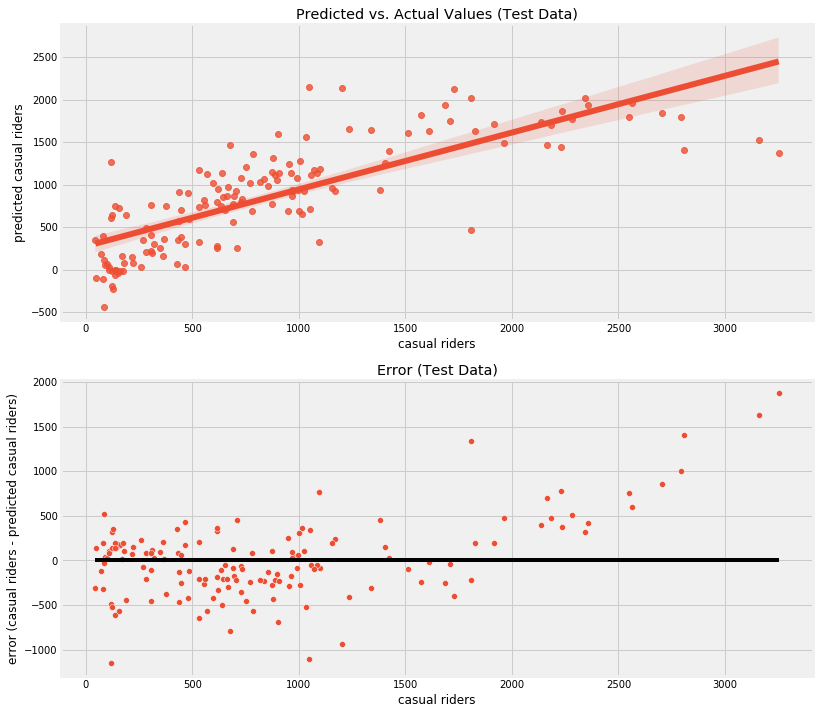

In [8]:
# run this cell to try your best model on the test data.
# if you get an error, make sure you ran the cell where you saved
# the parameters of your best model
X_test = make_X(bike_test, expl_vars)
y_test = bike_test[response_var]

if not intercept:
    X_test.drop("intercept", axis=1, inplace=True)

# make predictions
pred_test = X_test @ beta

# generate plots 
f, [ax1, ax2] = plt.subplots(2, figsize=(12, 12))

sns.regplot(x=y_test, y=pred_test, ax=ax1, color="#ED4E33") 
ax1.set_xlabel(response_var)
ax1.set_ylabel("predicted {}".format(response_var))
ax1.set_title("Predicted vs. Actual Values (Test Data)")

sns.scatterplot(x=y_test, y=y_test - pred_test, ax=ax2, color="#ED4E33") 
ax2.set_xlabel(response_var)
ax2.set_ylabel("error ({} - predicted {})".format(response_var, response_var))
ax2.set_title("Error (Test Data)")
ax2.hlines(y=0, xmin=min(y_test), xmax=max(y_test))


# calculate rmse
print("Test data RMSE = {}".format(np.sqrt(mse(pred_test, y_test))))


#### References
- Bike-Sharing data set from University of California Irvine's Machine Learning Repository https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset
- Portions of text and code adapted from Professor Jonathan Marshall's Legal Studies 190 (Data, Prediction, and Law) course materials: [lab 2-22-18, Linear Regression](https://github.com/ds-modules/LEGALST-190/tree/master/labs/2-22) (Author Keeley Takimoto)  and [lab 3-22-18, Exploratory Data Analysis](https://github.com/ds-modules/LEGALST-190/tree/masterlabs/3-22) (Author Keeley Takimoto)
- "Capital Bikeshare, Washington, DC" header image by [Leeann Caferatta](https://www.flickr.com/photos/leeanncafferata/34309356871) licensed under [CC BY-ND 2.0](https://creativecommons.org/licenses/by-nd/2.0/)